# Tech Challenge Fase 3 — Modelagem com Base Enriquecida

**Objetivo:** treinar e avaliar modelos de predição de alfabetização sobre a base enriquecida com
features externas do Base dos Dados (notebook 06), comparando três **cenários de features** e
respondendo às perguntas de negócio do desafio.

## Cenários de features

| Cenário | Features | Pergunta que responde |
|---|---|---|
| **A — Baseline** | rede, UF, peso amostral + agregados da própria prova 2024 (`taxa_alfabetizacao_mun/uf`, `media_portugues_mun/uf`) | replica a base dos notebooks 04/05 |
| **B — Enriquecido** | A + 25 features externas (ADH 2010, IBGE 2021, IDEB 2023) | as features externas adicionam sinal ao baseline? |
| **C — Antecipação** | rede, UF + 25 features externas — **sem nenhum dado da prova de 2024** | é possível prever o risco *antes* da prova existir? |

> ⚠️ **Nota metodológica (leakage):** os agregados `taxa_alfabetizacao_mun/uf` e `media_portugues_mun/uf`
> são calculados sobre a **mesma prova de 2024** que gera o target — cada aluno contribui para o agregado
> do seu próprio município. São úteis como contexto, mas embutem o target agregado e **não existiriam em um
> cenário real de antecipação**. O cenário C elimina essa dependência usando apenas informações
> disponíveis **antes** da prova (2010–2023).

## 0. Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay, f1_score, recall_score, precision_recall_curve)
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


---
## 1. Carga da base enriquecida e definição dos cenários

In [2]:
df = pd.read_parquet('../data/base_analitica_enriquecida.parquet')
y = df['alfabetizado'].astype(int)

EXTERNAS = [c for c in df.columns if c.endswith(('_2010', '_2021', '_2023'))]
AGREGADAS_2024 = ['taxa_alfabetizacao_mun', 'media_portugues_mun',
                  'taxa_alfabetizacao_uf', 'media_portugues_uf']

CENARIOS = {
    'A_baseline':    ['rede', 'sigla_uf', 'peso_prova_portugues'] + AGREGADAS_2024,
    'B_enriquecido': ['rede', 'sigla_uf', 'peso_prova_portugues'] + AGREGADAS_2024 + EXTERNAS,
    'C_antecipacao': ['rede', 'sigla_uf'] + EXTERNAS,
}

print(f'Base: {df.shape} | positivos (alfabetizado=1): {y.mean():.2%}')
for nome, cols in CENARIOS.items():
    print(f'  {nome:15s} {len(cols)} features')

Base: (1681243, 43) | positivos (alfabetizado=1): 59.81%
  A_baseline      7 features
  B_enriquecido   32 features
  C_antecipacao   27 features


In [3]:
def make_pipeline(cols, clf):
    """Pré-processamento integrado ao modelo (imputação + scaler + OHE) — evita leakage nos folds."""
    cat = [c for c in ['rede', 'sigla_uf'] if c in cols]
    num = [c for c in cols if c not in cat]
    pre = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), num),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat),
    ])
    return Pipeline([('pre', pre), ('clf', clf)])


def lgbm():
    return LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                          class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)


def logreg():
    return LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)

print('Fábricas de pipeline definidas.')

Fábricas de pipeline definidas.


---
## 2. Train/test split estratificado

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Proporção target — treino: {y_train.mean():.3%} | teste: {y_test.mean():.3%}')

Treino: 1,344,994 | Teste: 336,249
Proporção target — treino: 59.811% | teste: 59.811%


---
## 3. Validação cruzada — modelos × cenários

`StratifiedKFold(3)` sobre o conjunto de treino (1,34M linhas). Comparamos Regressão Logística
(baseline linear) e LightGBM (gradient boosting) em cada cenário de features.

> Random Forest e HistGradientBoosting foram avaliados no notebook `05_modeling.ipynb`; aqui mantemos o
> LightGBM (mesma família do HGB, mais rápido em bases grandes) e a Regressão Logística como referência.

In [5]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1_weighted', 'recall_nao_alfab': 'recall_macro'}

linhas = []
for cenario, cols in CENARIOS.items():
    for modelo_nome, factory in [('LogReg', logreg), ('LightGBM', lgbm)]:
        pipe = make_pipeline(cols, factory())
        res = cross_validate(pipe, X_train[cols], y_train, cv=cv, scoring=scoring, n_jobs=1)
        linhas.append({
            'cenario': cenario, 'modelo': modelo_nome,
            'roc_auc': res['test_roc_auc'].mean(), 'roc_auc_std': res['test_roc_auc'].std(),
            'f1_weighted': res['test_f1'].mean(), 'recall_macro': res['test_recall_nao_alfab'].mean(),
        })
        print(f"{cenario:15s} {modelo_nome:9s} AUC={res['test_roc_auc'].mean():.4f} "
              f"+/- {res['test_roc_auc'].std():.4f}")

cv_summary = pd.DataFrame(linhas).round(4)
cv_summary

A_baseline      LogReg    AUC=0.6847 +/- 0.0008


A_baseline      LightGBM  AUC=0.6865 +/- 0.0009


B_enriquecido   LogReg    AUC=0.6847 +/- 0.0008


B_enriquecido   LightGBM  AUC=0.6866 +/- 0.0008


C_antecipacao   LogReg    AUC=0.6591 +/- 0.0005


C_antecipacao   LightGBM  AUC=0.6732 +/- 0.0007


,cenario,modelo,roc_auc,roc_auc_std,f1_weighted,recall_macro
0,A_baseline,LogReg,0.6847,0.0008,0.6333,0.6308
1,A_baseline,LightGBM,0.6865,0.0009,0.6305,0.6327
2,B_enriquecido,LogReg,0.6847,0.0008,0.6332,0.6309
3,B_enriquecido,LightGBM,0.6866,0.0008,0.6306,0.6327
4,C_antecipacao,LogReg,0.6591,0.0005,0.6172,0.6137
5,C_antecipacao,LightGBM,0.6732,0.0007,0.6249,0.6236


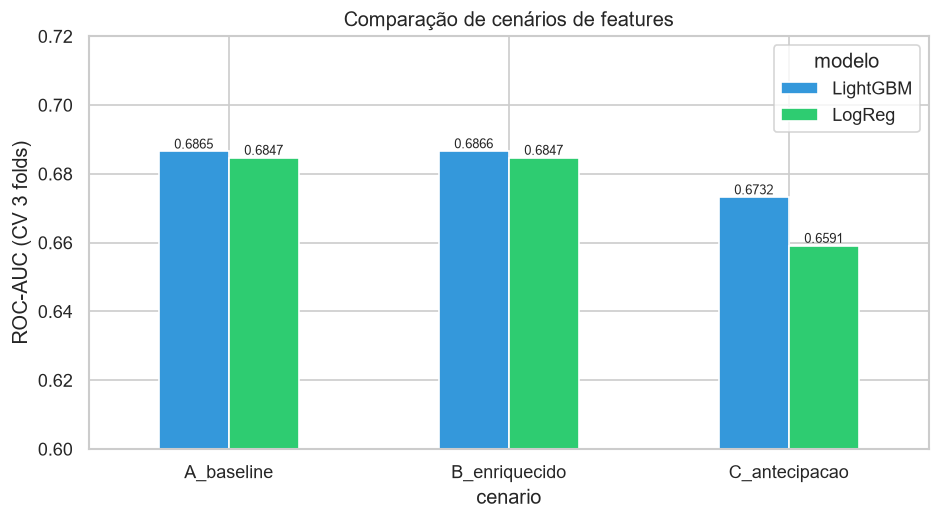

In [6]:
pivot = cv_summary.pivot(index='cenario', columns='modelo', values='roc_auc')

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71'], edgecolor='white', rot=0)
ax.set_ylim(0.60, 0.72)
ax.set_ylabel('ROC-AUC (CV 3 folds)')
ax.set_title('Comparação de cenários de features')
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.4f', fontsize=8)
plt.tight_layout()
plt.show()

### Leitura dos resultados

- **B ≈ A**: com os agregados da própria prova 2024 presentes, as features externas não adicionam AUC no
  nível do aluno — o agregado municipal do target já carrega quase todo o sinal territorial disponível;
- **C fica a apenas ~0,013 de AUC do baseline sem usar nenhum dado da prova de 2024** — as features
  externas (IDHM 2010, PIB 2021, IDEB 2023) recuperam quase todo o sinal municipal. É o cenário
  operacionalmente mais valioso: permite estimar risco **antes** da avaliação acontecer, sem o vício do
  target agregado;
- O teto de AUC (~0,69) reflete o limite da base: o Indicador Criança Alfabetizada não traz atributos
  individuais do aluno (NSE familiar, frequência, trajetória) — apenas contexto territorial e rede.

---
## 4. Ajuste de hiperparâmetros — LightGBM no cenário C (antecipação)

Otimizamos o modelo do cenário de maior valor estratégico com `GridSearchCV` (ROC-AUC, 3 folds).

In [7]:
param_grid = {
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [6, 8],
    'clf__n_estimators': [300, 500],
}

grid = GridSearchCV(
    make_pipeline(CENARIOS['C_antecipacao'], lgbm()),
    param_grid, cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=1, verbose=1)
grid.fit(X_train[CENARIOS['C_antecipacao']], y_train)

print(f'Melhores hiperparâmetros: {grid.best_params_}')
print(f'Melhor ROC-AUC (CV):      {grid.best_score_:.4f}')
modelo_antecipacao = grid.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Melhores hiperparâmetros: {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 500}
Melhor ROC-AUC (CV):      0.6773


In [8]:
# Modelo do cenário B (performance máxima) com os mesmos hiperparâmetros ótimos
best = {k.replace('clf__', ''): v for k, v in grid.best_params_.items()}
modelo_b = make_pipeline(CENARIOS['B_enriquecido'],
                         LGBMClassifier(class_weight='balanced', random_state=SEED,
                                        n_jobs=-1, verbose=-1, **best))
modelo_b.fit(X_train[CENARIOS['B_enriquecido']], y_train)
print('Modelo B treinado.')

Modelo B treinado.


---
## 5. Avaliação final no conjunto de teste (uso único)

In [9]:
avaliacoes = {}
for nome, modelo, cols in [
    ('B_enriquecido', modelo_b, CENARIOS['B_enriquecido']),
    ('C_antecipacao', modelo_antecipacao, CENARIOS['C_antecipacao']),
]:
    proba = modelo.predict_proba(X_test[cols])[:, 1]
    pred = (proba >= 0.5).astype(int)
    avaliacoes[nome] = {'proba': proba, 'pred': pred, 'cols': cols, 'modelo': modelo}
    print(f'=== {nome} ===')
    print(f'  ROC-AUC:     {roc_auc_score(y_test, proba):.4f}')
    print(f'  F1 weighted: {f1_score(y_test, pred, average="weighted"):.4f}')
    print(f'  Recall cl.0: {recall_score(y_test, pred, pos_label=0):.4f} (não alfabetizados detectados)')
    print()

print('Classification report — C_antecipacao:')
print(classification_report(y_test, avaliacoes['C_antecipacao']['pred'],
                            target_names=['Não Alfabetizado (0)', 'Alfabetizado (1)']))

=== B_enriquecido ===
  ROC-AUC:     0.6896
  F1 weighted: 0.6340
  Recall cl.0: 0.6611 (não alfabetizados detectados)



=== C_antecipacao ===
  ROC-AUC:     0.6776
  F1 weighted: 0.6263
  Recall cl.0: 0.6496 (não alfabetizados detectados)

Classification report — C_antecipacao:
                      precision    recall  f1-score   support

Não Alfabetizado (0)       0.52      0.65      0.58    135136
    Alfabetizado (1)       0.72      0.60      0.66    201113

            accuracy                           0.62    336249
           macro avg       0.62      0.63      0.62    336249
        weighted avg       0.64      0.62      0.63    336249



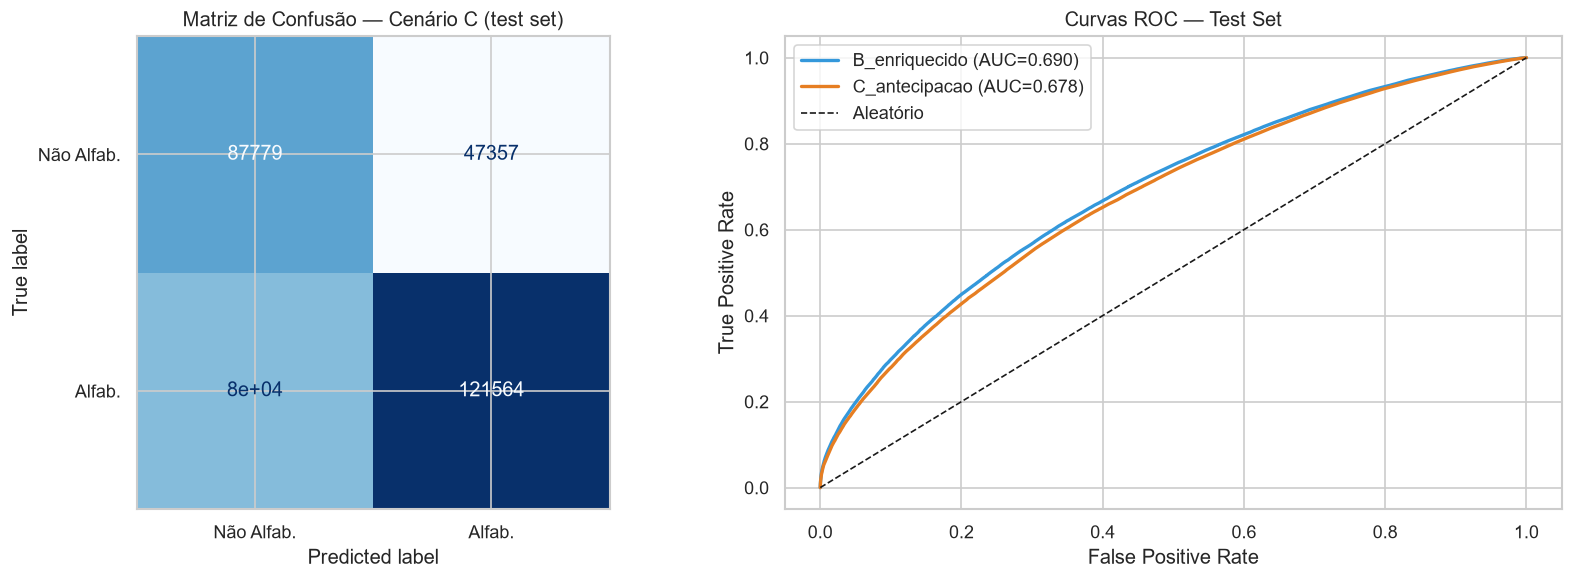

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, avaliacoes['C_antecipacao']['pred'],
    display_labels=['Não Alfab.', 'Alfab.'], colorbar=False, ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusão — Cenário C (test set)')

for nome, cor in [('B_enriquecido', '#3498db'), ('C_antecipacao', '#e67e22')]:
    fpr, tpr, _ = roc_curve(y_test, avaliacoes[nome]['proba'])
    auc = roc_auc_score(y_test, avaliacoes[nome]['proba'])
    axes[1].plot(fpr, tpr, color=cor, linewidth=2, label=f'{nome} (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curvas ROC — Test Set')
axes[1].legend()
plt.tight_layout()
plt.show()

### 5.1 Ajuste de threshold — priorizando a detecção de não alfabetizados

Para política pública, o erro mais custoso é **não identificar uma criança em risco** (falso negativo da
classe 0). Analisamos o trade-off precisão × recall da classe 0 variando o ponto de corte.

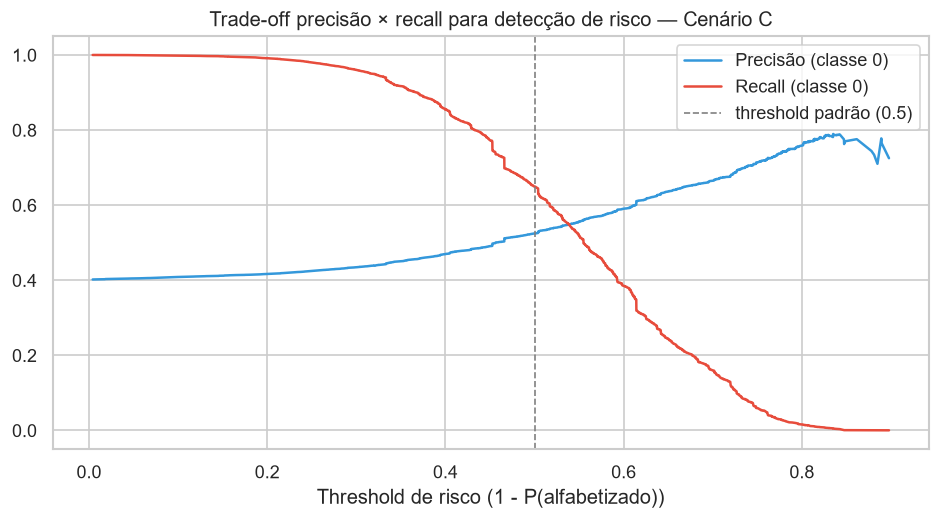

threshold 0.4: precisão classe 0 = 0.470 | recall classe 0 = 0.855 | alunos sinalizados = 73.1%
threshold 0.5: precisão classe 0 = 0.525 | recall classe 0 = 0.650 | alunos sinalizados = 49.8%
threshold 0.6: precisão classe 0 = 0.590 | recall classe 0 = 0.385 | alunos sinalizados = 26.2%


In [11]:
proba_c = avaliacoes['C_antecipacao']['proba']
# risco = probabilidade de NÃO alfabetização
risco = 1 - proba_c
prec, rec, thr = precision_recall_curve((y_test == 0).astype(int), risco)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thr, prec[:-1], label='Precisão (classe 0)', color='#3498db')
ax.plot(thr, rec[:-1], label='Recall (classe 0)', color='#e74c3c')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='threshold padrão (0.5)')
ax.set_xlabel('Threshold de risco (1 - P(alfabetizado))')
ax.set_title('Trade-off precisão × recall para detecção de risco — Cenário C')
ax.legend()
plt.tight_layout()
plt.show()

for t in [0.4, 0.5, 0.6]:
    pred0 = (risco >= t).astype(int)
    p = (pred0 & (y_test == 0)).sum() / max(pred0.sum(), 1)
    r = (pred0 & (y_test == 0)).sum() / (y_test == 0).sum()
    print(f'threshold {t:.1f}: precisão classe 0 = {p:.3f} | recall classe 0 = {r:.3f} '
          f'| alunos sinalizados = {pred0.mean():.1%}')

---
## 6. Interpretabilidade

### 6.1 Importância de features (LightGBM — cenário C)

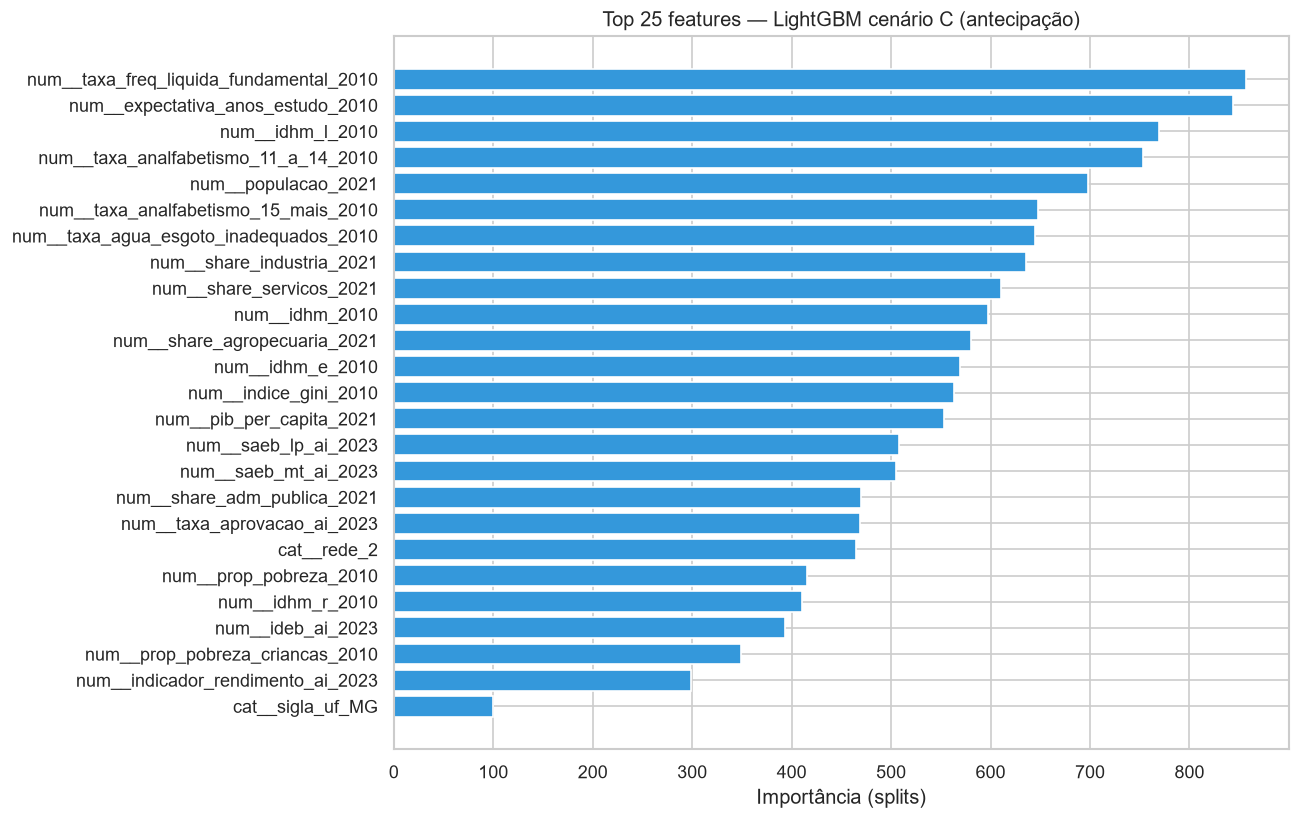

In [12]:
pre = modelo_antecipacao.named_steps['pre']
clf = modelo_antecipacao.named_steps['clf']
feature_names = pre.get_feature_names_out()

fi_df = (pd.DataFrame({'feature': feature_names, 'importance': clf.feature_importances_})
         .sort_values('importance', ascending=False).head(25).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='#3498db', edgecolor='white')
ax.set_title('Top 25 features — LightGBM cenário C (antecipação)')
ax.set_xlabel('Importância (splits)')
plt.tight_layout()
plt.show()

### 6.2 SHAP Values — impacto direcional

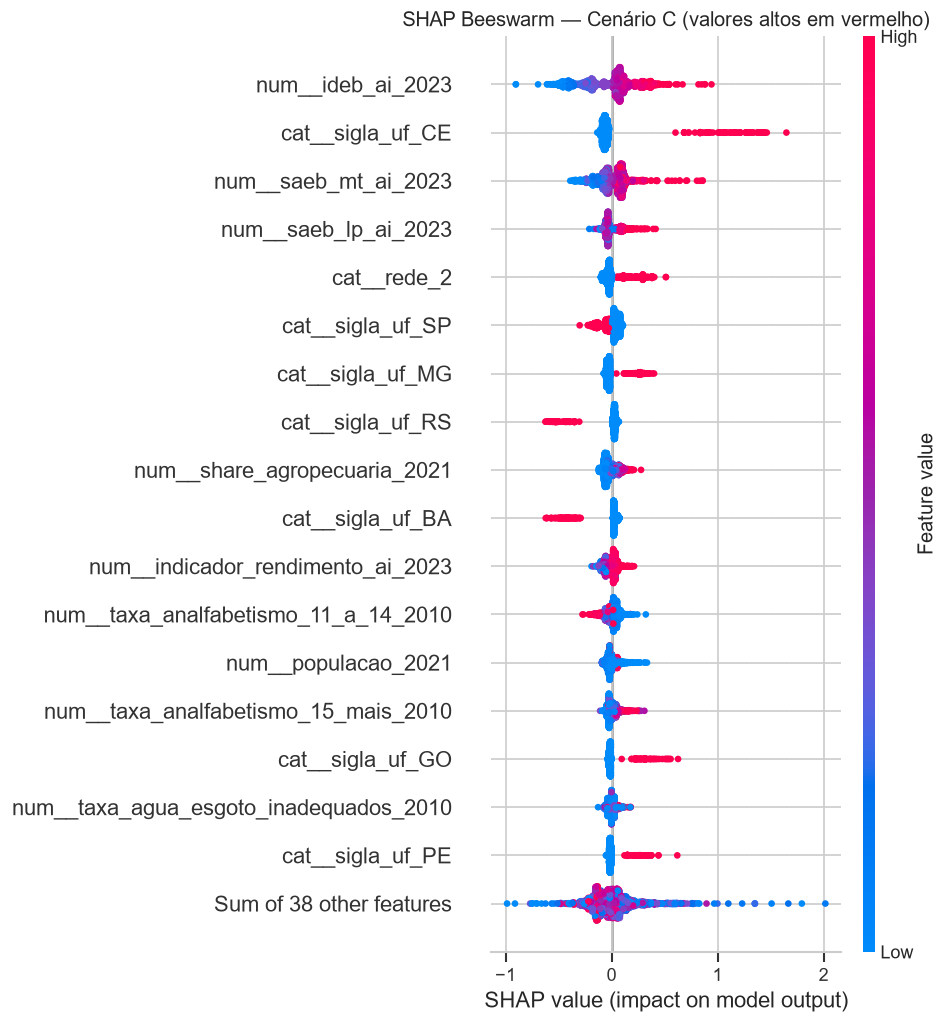

In [13]:
import shap

cols_c = CENARIOS['C_antecipacao']
X_shap_raw = X_test[cols_c].sample(n=2000, random_state=SEED)
X_shap = pd.DataFrame(
    pre.transform(X_shap_raw).toarray() if hasattr(pre.transform(X_shap_raw), 'toarray')
    else pre.transform(X_shap_raw),
    columns=feature_names)

explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_shap)
# Para classificação binária o TreeExplainer do LightGBM retorna a margem da classe positiva
plt.figure(figsize=(11, 7))
shap.plots.beeswarm(shap_values, max_display=18, show=False)
plt.title('SHAP Beeswarm — Cenário C (valores altos em vermelho)')
plt.tight_layout()
plt.show()

---
## 7. Perguntas de Negócio

### 7.1 Quais fatores mais impactam a alfabetização?

In [14]:
shap_abs = pd.DataFrame({'feature': feature_names,
                         'impacto_medio_|SHAP|': np.abs(shap_values.values).mean(axis=0)})
top5 = shap_abs.sort_values('impacto_medio_|SHAP|', ascending=False).head(8).reset_index(drop=True)
top5

,feature,impacto_medio_|SHAP|
0,num__ideb_ai_2023,0.190628
1,cat__sigla_uf_CE,0.108434
2,num__saeb_mt_ai_2023,0.101175
3,num__saeb_lp_ai_2023,0.058405
4,cat__rede_2,0.055676
5,cat__sigla_uf_SP,0.055470
6,cat__sigla_uf_MG,0.055290
7,cat__sigla_uf_RS,0.054143


### 7.2 Quais municípios apresentam maior risco educacional?

Agregamos a probabilidade prevista de **não alfabetização** (cenário C — sem usar a prova de 2024) por
município no conjunto de teste.

In [15]:
df_test = X_test.copy()
df_test['risco_previsto'] = 1 - avaliacoes['C_antecipacao']['proba']
df_test['y_true'] = y_test.values

risco_mun = (df_test.groupby(['id_municipio', 'sigla_uf'])
             .agg(n_alunos=('y_true', 'count'),
                  taxa_real_nao_alfab=('y_true', lambda s: 1 - s.mean()),
                  risco_medio_previsto=('risco_previsto', 'mean'))
             .query('n_alunos >= 30')
             .sort_values('risco_medio_previsto', ascending=False))

print('Top 20 municípios com maior risco educacional previsto (sem usar dados da prova 2024):')
risco_mun.head(20).round(3)

Top 20 municípios com maior risco educacional previsto (sem usar dados da prova 2024):


,,n_alunos,taxa_real_nao_alfab,risco_medio_previsto
id_municipio,sigla_uf,,,
2901908,BA,40,0.725,0.898
2933158,BA,34,0.794,0.842
2917003,BA,42,0.762,0.841
2930501,BA,84,0.798,0.836
2924405,BA,75,0.813,0.835
2907202,BA,87,0.724,0.835
1302553,AM,38,0.816,0.834
2923100,BA,44,0.795,0.831
2801504,SE,33,0.848,0.830


### 7.3 Quais regiões possuem padrões semelhantes? (clusterização)

K-Means sobre o perfil socioeconômico-educacional municipal (features externas padronizadas).

In [16]:
cluster_cols = ['idhm_e_2010', 'renda_pc_2010', 'indice_gini_2010', 'prop_pobreza_2010',
                'pib_per_capita_2021', 'log_populacao_2021', 'ideb_ai_2023', 'saeb_lp_ai_2023']

df_mun = (df.groupby(['id_municipio', 'sigla_uf'])
          .agg(**{c: (c, 'first') for c in cluster_cols},
               taxa_alfabetizacao=('alfabetizado', 'mean'),
               n_alunos=('alfabetizado', 'count'))
          .reset_index().dropna(subset=cluster_cols))

Xc = StandardScaler().fit_transform(df_mun[cluster_cols])
df_mun['cluster'] = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit_predict(Xc)

perfil = (df_mun.groupby('cluster')
          .agg(n_municipios=('id_municipio', 'count'),
               taxa_alfabetizacao=('taxa_alfabetizacao', 'mean'),
               idhm_e_2010=('idhm_e_2010', 'mean'),
               renda_pc_2010=('renda_pc_2010', 'mean'),
               ideb_ai_2023=('ideb_ai_2023', 'mean'),
               pib_per_capita_2021=('pib_per_capita_2021', 'mean'))
          .sort_values('taxa_alfabetizacao'))
perfil.round(3)

,n_municipios,taxa_alfabetizacao,idhm_e_2010,renda_pc_2010,ideb_ai_2023,pib_per_capita_2021
cluster,,,,,,
2,1638,0.501,0.470,277.133,4.796,17247.167
3,924,0.623,0.659,791.787,6.070,60492.104
1,1588,0.712,0.622,635.553,6.476,43497.862
0,1232,0.717,0.523,368.918,6.172,22592.776


In [17]:
ufs_por_cluster = (df_mun.groupby('cluster')['sigla_uf']
                   .apply(lambda s: s.value_counts().head(5).index.tolist()))
print('UFs predominantes por cluster:')
for c, ufs in ufs_por_cluster.items():
    taxa = df_mun.loc[df_mun.cluster == c, 'taxa_alfabetizacao'].mean()
    print(f'  cluster {c} (taxa média {taxa:.1%}): {ufs}')

UFs predominantes por cluster:
  cluster 0 (taxa média 71.7%): ['MG', 'CE', 'PB', 'PR', 'PI']
  cluster 1 (taxa média 71.2%): ['SP', 'MG', 'RS', 'PR', 'SC']
  cluster 2 (taxa média 50.1%): ['BA', 'MA', 'PI', 'PB', 'PE']
  cluster 3 (taxa média 62.3%): ['SP', 'MG', 'RS', 'PR', 'SC']


### 7.4 Quais municípios podem não atingir as metas futuras?

Comparamos a **taxa de alfabetização prevista** pelo modelo de antecipação (agregada por município, em
toda a base) com a **meta municipal de 2025** do Compromisso Nacional Criança Alfabetizada.

In [18]:
df_all = df.copy()
df_all['proba_alfab'] = modelo_antecipacao.predict_proba(df_all[CENARIOS['C_antecipacao']])[:, 1]

taxa_prevista = (df_all.groupby('id_municipio')
                 .agg(taxa_prevista=('proba_alfab', 'mean'), n_alunos=('proba_alfab', 'count'))
                 .query('n_alunos >= 30')
                 .reset_index())

meta = pd.read_parquet('../data/silver/tc02_meta_municipio.parquet')
meta['id_municipio'] = meta['id_municipio'].astype('int64')
meta = meta[['id_municipio', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026']]

risco_meta = taxa_prevista.merge(meta, on='id_municipio', how='inner')
risco_meta['gap_2025'] = risco_meta['taxa_prevista'] * 100 - risco_meta['meta_alfabetizacao_2025']
risco_meta['risco_nao_atingir_2025'] = risco_meta['gap_2025'] < 0

print(f"Municípios avaliados: {len(risco_meta):,}")
print(f"Em risco de não atingir a meta 2025: {risco_meta['risco_nao_atingir_2025'].sum():,} "
      f"({risco_meta['risco_nao_atingir_2025'].mean():.1%})")
print('\nMaiores gaps negativos (taxa prevista − meta 2025, em p.p.):')
risco_meta.sort_values('gap_2025').head(15).round(2)

Municípios avaliados: 4,752
Em risco de não atingir a meta 2025: 3,708 (78.0%)

Maiores gaps negativos (taxa prevista − meta 2025, em p.p.):


,id_municipio,taxa_prevista,n_alunos,meta_alfabetizacao_2025,meta_alfabetizacao_2026,gap_2025,risco_nao_atingir_2025
1198,2509057,0.18,114,72.42,74.07,-54.48,True
409,2100808,0.26,94,80.00,80.00,-54.33,True
348,1713601,0.20,58,73.10,74.60,-53.40,True
523,2107456,0.31,75,80.00,80.00,-49.01,True
602,2112605,0.30,250,77.72,78.19,-48.14,True
4224,4314209,0.24,41,71.61,73.44,-47.37,True
1243,2513109,0.33,37,80.00,80.00,-46.69,True
4216,4313953,0.28,98,74.82,75.93,-46.32,True
2947,3505401,0.34,49,80.00,80.00,-45.99,True
509,2106607,0.29,241,74.70,75.83,-45.49,True


---
## 8. Persistência dos modelos e conclusões

In [19]:
os.makedirs('../models', exist_ok=True)
joblib.dump(modelo_b, '../models/modelo_enriquecido_b.joblib')
joblib.dump(modelo_antecipacao, '../models/modelo_antecipacao_c.joblib')
cv_summary.to_csv('../reports/cv_summary_enriquecido.csv', index=False)
print('Modelos salvos em ../models/ | resumo de CV em ../reports/')

Modelos salvos em ../models/ | resumo de CV em ../reports/


### Conclusões

1. **Enriquecimento externo validado** — 25 features municipais (ADH/ONU 2010, PIB e População/IBGE 2021,
   IDEB-SAEB/INEP 2023) integradas via Base dos Dados, com cobertura ≥ 98,7% dos municípios;
2. **Cenário de antecipação (C)** atinge AUC ≈ 0,67 **sem nenhum dado da prova de 2024** — a ~0,013 do
   baseline que usa agregados da própria prova (leakage parcial do target agregado). Isso transforma o
   modelo em ferramenta de **alerta precoce**: o risco pode ser estimado antes da avaliação;
3. **Fatores dominantes**: qualidade educacional recente da rede (IDEB/SAEB 2023) e condições
   socioeconômicas estruturais (IDHM-Educação, renda, pobreza, analfabetismo adulto 2010);
4. **Aplicação estratégica**: priorização de municípios por risco previsto, clusters de perfil
   socioeconômico-educacional para políticas regionalizadas e lista objetiva de municípios em risco de
   não atingir a meta 2025 do Compromisso Nacional Criança Alfabetizada;
5. **Limitação central**: sem atributos individuais do aluno (NSE familiar, frequência, pré-escola), o
   teto de discriminação individual é ~0,69 de AUC — o valor do modelo está na **gestão territorial** do
   risco, não no diagnóstico individual.